In [2]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Avrah\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Fri Jul 24 19:04:29 2026).


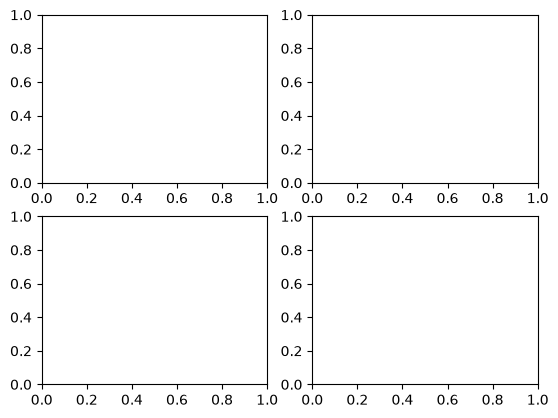

In [ ]:
fig, ax = plt.subplots(2,2) #rows THEN columns (y THEN x)

<Axes: xlabel='job_title_short'>

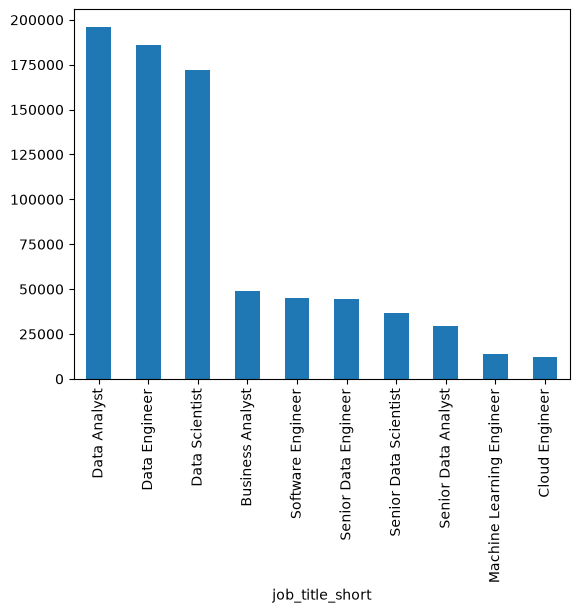

In [4]:
df['job_title_short'].value_counts().plot(kind='bar')

In [5]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

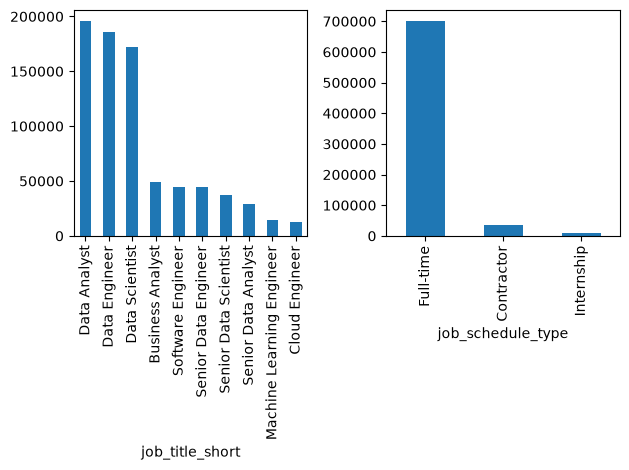

In [6]:
fig,ax = plt.subplots(1,2) #rows THEN columns

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0]) #ax list is inclusive (0=first)
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

fig.tight_layout() #'tight_layout is used to prevent graphs overlapping

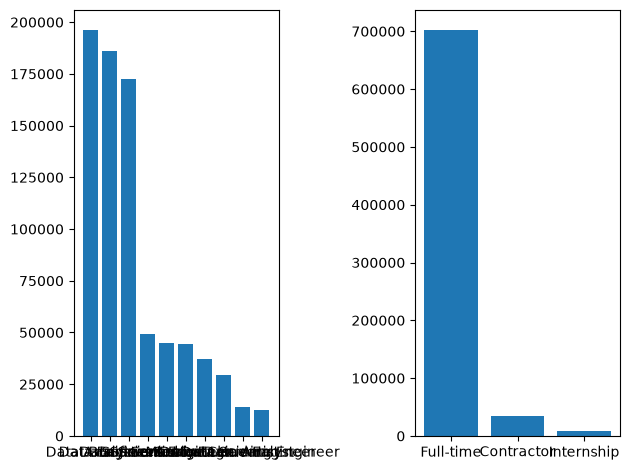

In [7]:
#in order to use ONLY matplotlib syntax:
fig,ax = plt.subplots(1,2)

ax[0].bar(df['job_title_short'].value_counts().index, df['job_title_short'].value_counts())
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index,df['job_schedule_type'].value_counts().head(3) )

fig.tight_layout()

# Example - Count Top Skills in Job Postings

In [8]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

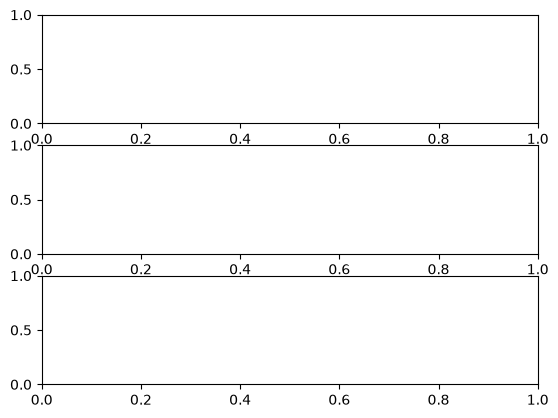

In [9]:
fig, ax = plt.subplots(3,1)

In [13]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [11]:
#Enumerate counts number of values in the list?

for i, job_title in enumerate(job_titles):
    print(i,job_title)

0 Data Scientist
1 Data Engineer
2 Data Analyst


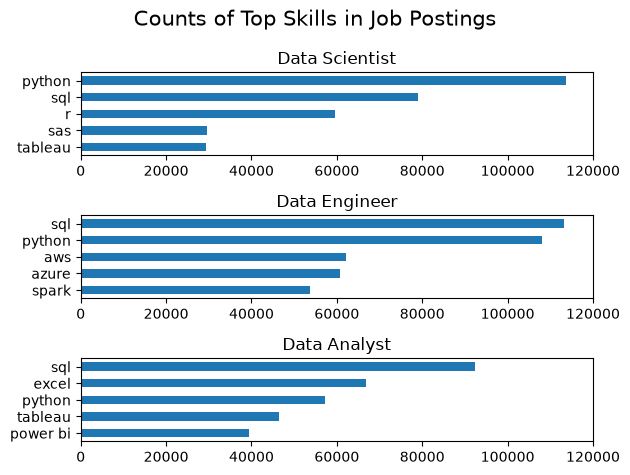

In [12]:
fig,ax = plt.subplots(3,1)

#job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']
for i, job_title in enumerate(job_titles):
    #top 5 skills for each role title in the job_titles list
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    #ploting each role using only 'df_plot' while referencing different roles using i variable defined in the loop
    df_plot.plot(kind="barh", x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    #for each plotted i, call these methods:
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)

fig.suptitle("Counts of Top Skills in Job Postings", fontsize=15)
fig.tight_layout()